In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Dataset Shape:
(284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.

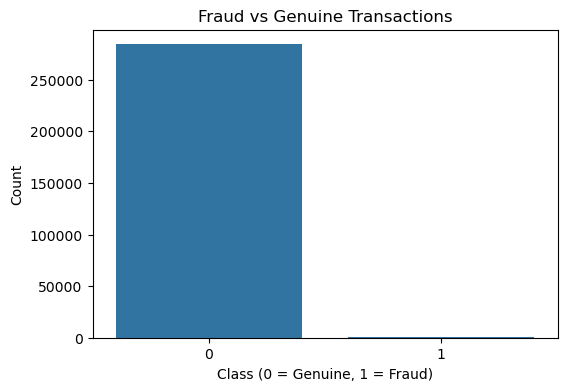


Feature Shape: (284807, 30)
Target Shape: (284807,)

Applying SMOTE...
Before SMOTE:
Class
0    284315
1       492
Name: count, dtype: int64

After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64

Training Logistic Regression...

========== Logistic Regression ==========
Accuracy: 0.9489035049153228
Precision: 0.9743737135863821
Recall: 0.9222655153046897
F1 Score: 0.9476038050583833

Training Random Forest...

========== Random Forest ==========
Accuracy: 0.999903276295658
Precision: 0.9998069735202766
Recall: 1.0
F1 Score: 0.9999034774444338
ROC AUC Score: 0.9999990915102054

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



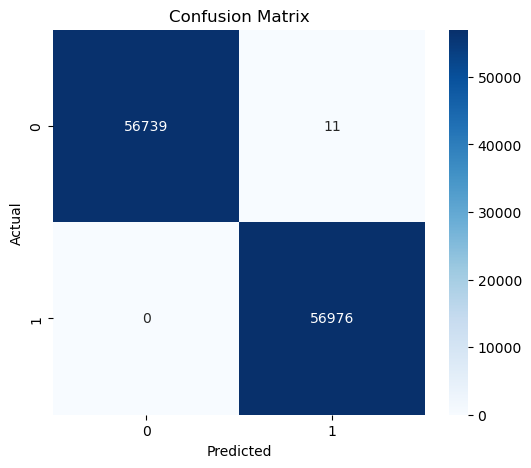


Top 10 Important Features:
   Feature  Importance
14     V14    0.192994
10     V10    0.114421
4       V4    0.103551
12     V12    0.100798
17     V17    0.079601
16     V16    0.056069
11     V11    0.055625
3       V3    0.050643
2       V2    0.037681
9       V9    0.025641


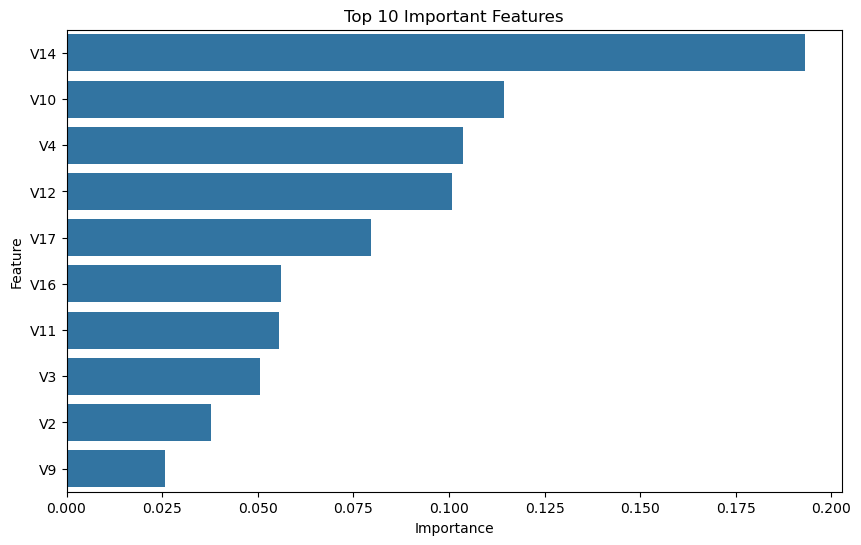


Model saved successfully as fraud_model.pkl

Prediction: FRAUDULENT TRANSACTION


In [2]:
# ============================================================
# CREDIT CARD FRAUD DETECTION USING MACHINE LEARNING
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# FRAUD DISTRIBUTION
# ============================================================

print("\nClass Distribution:")
print(df['Class'].value_counts())

print("\nPercentage Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

# ============================================================
# VISUALIZE CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# ============================================================
# SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop('Class', axis=1)
y = df['Class']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

# ============================================================
# HANDLE CLASS IMBALANCE USING SMOTE
# ============================================================

print("\nApplying SMOTE...")

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

print("\nTraining Logistic Regression...")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n========== Logistic Regression ==========")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

# ============================================================
# RANDOM FOREST MODEL
# ============================================================

print("\nTraining Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:, 1]

print("\n========== Random Forest ==========")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC AUC Score:",
      roc_auc_score(y_test, rf_prob))

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

pickle.dump(
    rf,
    open("fraud_model.pkl", "wb")
)

print("\nModel saved successfully as fraud_model.pkl")

# ============================================================
# SAMPLE PREDICTION
# ============================================================

sample_transaction = X_test.iloc[0:1]

prediction = rf.predict(sample_transaction)

if prediction[0] == 1:
    print("\nPrediction: FRAUDULENT TRANSACTION")
else:
    print("\nPrediction: GENUINE TRANSACTION")

# ============================================================
# END OF PROJECT
# ============================================================